# 🧪 Analíticas de sangre (tabular) — **v1 LIGERO** (CPU · modelo independiente)
## TFM · Módulo Tabular (Laboratorio) · Universidad de Salamanca

---

## 🎯 Qué es esta versión (la más ligera de las 3)
La señal tabular tiene techo (~0.67–0.69 AUC). Esta versión es la **línea base rápida**: un **único XGBoost**
one-vs-rest que aprovecha el **manejo nativo de NaN** de los árboles (no hace falta imputar) y unas pocas
**variables clínicas derivadas**.

| Las 3 versiones | Modelo | Coste CPU |
|---|---|---|
| **v1 (esta, ligera)** | **un XGBoost** one-vs-rest tuneado (ligero) | **minutos** |
| v2 (óptima) | ensemble XGB+LightGBM+LogReg+MLP con tuning por modelo | ~1 h |
| v3 (pesada) | v2 + TabPFN (nube) + stacking de 2º nivel de los tabulares | ~horas |

## 🛡️ Bases del proyecto (intactas)
Masking de NaN/−1 · **negativos derivados por exclusividad de *No Finding*** · **sin `cxr_view`** · **flags de
missingness** (MNAR) · `scale_pos_weight` por etiqueta · **calibración isotónica** · **OOF sin fuga** · nombres legibles.


In [1]:
# CELDA 1 · DEPENDENCIAS
import subprocess, sys
for p in ["xgboost","scikit-learn","pandas","numpy","matplotlib","seaborn"]:
    subprocess.run([sys.executable,"-m","pip","install",p,"-q"], check=False)
print("Dependencias listas.")

Dependencias listas.


In [2]:
# CELDA 2 · IMPORTS, RUTAS Y CONSTANTES
import json, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import KFold
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             confusion_matrix, roc_curve, precision_recall_curve)
import xgboost as xgb
warnings.filterwarnings("ignore"); SEED=42; np.random.seed(SEED)

BASE=Path(r"C:\TFM\1.Opción - Symile Mimic\symile-mimic-a-multimodal-clinical-dataset-of-chest-x-rays-electrocardiograms-and-blood-labs-from-mimic-iv-1.0.0")
CSV=BASE/"data_csv"/"clean"
TRAIN_CSV,VAL_CSV,TEST_CSV=CSV/"train_clean.csv",CSV/"val_clean.csv",CSV/"test_clean.csv"
OUTPUT_DIR=Path("outputs_labs_tabular_v1"); OUTPUT_DIR.mkdir(exist_ok=True); FIG=OUTPUT_DIR/"figuras"; FIG.mkdir(exist_ok=True)

LABELS=["Atelectasis","Cardiomegaly","Edema","Lung Opacity","No Finding","Pleural Effusion"]
N_LABELS=len(LABELS); NO_FINDING="No Finding"
PATHOLOGY=[l for l in LABELS if l!=NO_FINDING]; CORE=["Cardiomegaly","Edema","Pleural Effusion"]
K_FOLDS=5; FLAG_THRESH=0.02
GENDER={0:0,1:1,"0":0,"1":1,"M":1,"F":0}; RACE={"UNKNOWN":0,"WHITE":1,"BLACK":2,"ASIAN":3,"HISPANIC_LATINO":4,"OTHER_KNOWN":0}
ADM={"SCHEDULED":0,"EMERGENCY":1,"OBSERVATION":2,"URGENT":3}; LOC={"EMERGENCY_ROOM":0,"REFERRAL":1,"TRANSFER":2,"INTRA_HOSPITAL":3}
print("Salidas en", OUTPUT_DIR)

Salidas en outputs_labs_tabular_v1


In [3]:
# CELDA 3 · CARGA + OBJETIVOS (masking de NaN/−1 + negativos derivados por exclusividad)
df_train=pd.read_csv(TRAIN_CSV,sep=";"); df_val=pd.read_csv(VAL_CSV,sep=";"); df_test=pd.read_csv(TEST_CSV,sep=";")
DEMO=["subject_id","hadm_id","cxr_path","ecg_path","age","gender","race","admission_type","admission_location","cxr_view","hours_adm_to_cxr"]
RAW_LABS=[c for c in df_train.columns if c not in LABELS and c not in DEMO and "pctile" not in c]
def build_targets(df, uncertainty_policy="zeros", derive=True, verbose=False):
    raw=df[LABELS].to_numpy(dtype=float); N=raw.shape[0]
    labels=np.zeros((N,N_LABELS),np.float32); mask=np.zeros((N,N_LABELS),np.float32)
    mask[~np.isnan(raw)]=1.0; labels[raw==1]=1.0
    unc=(raw==-1); labels[unc]=1.0 if uncertainty_policy=="ones" else 0.0
    nf=LABELS.index(NO_FINDING); pc=[j for j in range(N_LABELS) if j!=nf]; ndp=ndn=0
    if derive:
        nfp=(raw[:,nf]==1)
        for j in pc:
            f=nfp&np.isnan(raw[:,j]); labels[f,j]=0.0; mask[f,j]=1.0; ndp+=int(f.sum())
        ap=(raw[:,pc]==1).any(1); fn=ap&np.isnan(raw[:,nf]); labels[fn,nf]=0.0; mask[fn,nf]=1.0; ndn=int(fn.sum())
    if verbose: print(f"   negativos derivados -> patologías={ndp:,} · No Finding={ndn:,}")
    return labels,mask
y_train,m_train=build_targets(df_train,verbose=True); y_val,m_val=build_targets(df_val); y_test,m_test=build_targets(df_test)
print(f"train={len(df_train)} val={len(df_val)} test={len(df_test)} · {len(RAW_LABS)} analíticas")

   negativos derivados -> patologías=6,091 · No Finding=7,691
train=10000 val=750 test=464 · 41 analíticas


In [4]:
# CELDA 4 · FEATURES: analíticas (NaN nativo) + ratios clínicos + flags de missingness + demografía
train_miss=df_train[RAW_LABS].isna().mean(); FLAG_LABS=[c for c in RAW_LABS if train_miss[c]>FLAG_THRESH]
def _col(key):
    for c in RAW_LABS:
        if c.startswith(key+"_") or c==key: return c
    return None
C_UREA=_col("urea_nitrogen"); C_CREAT=_col("creatinine"); C_NEUT=_col("neutrophils_pct"); C_LYMPH=_col("lymphocytes_pct"); C_RDW=_col("rdw")
def ratios(df):
    g=lambda c: df[c].to_numpy(np.float32) if c else np.full(len(df),np.nan,np.float32)
    urea,creat,neut,lymph,rdw=g(C_UREA),g(C_CREAT),g(C_NEUT),g(C_LYMPH),g(C_RDW); age=df["age"].astype(float).to_numpy(np.float32)
    out=np.vstack([urea/(creat+1e-6), neut/(lymph+1e-6), rdw*age/100.0]).T.astype(np.float32)
    return out,["BUN/Creatinina","Neutrófilos/Linfocitos","RDW×Edad"]
def demo(df):
    n=len(df); cols=[df["age"].astype(float).to_numpy()[:,None], df["gender"].map(lambda v:float(GENDER.get(v,0))).to_numpy()[:,None]]
    names=["Edad","Sexo"]
    def oh(s,mp,pref):
        M=np.zeros((n,max(mp.values())+1),np.float32)
        for i,v in enumerate(s): M[i,mp.get(str(v).upper(),0)]=1.0
        return M,[f"{pref}={k}" for k,_ in sorted(mp.items(),key=lambda x:x[1])][:M.shape[1]]
    for c,mp,pref in [("race",RACE,"Raza"),("admission_type",ADM,"Ingreso"),("admission_location",LOC,"Lugar")]:
        M,nm=oh(df[c],mp,pref); cols.append(M); names+=nm
    cols.append(df["hours_adm_to_cxr"].astype(float).to_numpy()[:,None]); names.append("Horas ingreso→CXR")
    return np.hstack(cols).astype(np.float32),names
def features(df):
    r,rn=ratios(df); d,dn=demo(df)
    X=np.hstack([df[RAW_LABS].to_numpy(np.float32), r, df[FLAG_LABS].isna().astype(np.float32).to_numpy(), d])
    names=[c.rsplit("_",1)[0].replace("_"," ").title() for c in RAW_LABS]+rn+[f"falta:{c.rsplit('_',1)[0]}" for c in FLAG_LABS]+dn
    return X,names
X_train,FEAT_NAMES=features(df_train); X_val,_=features(df_val); X_test,_=features(df_test)
print(f"Features: {X_train.shape[1]} ({len(FLAG_LABS)} flags de missingness) · XGBoost maneja los NaN nativamente")

Features: 84 (24 flags de missingness) · XGBoost maneja los NaN nativamente


In [5]:
# CELDA 5 · MÉTRICAS + XGBoost one-vs-rest (con masking y balanceo por etiqueta)
def multilabel_metrics(probs,labels,mask,thresholds=None):
    if thresholds is None: thresholds={l:0.5 for l in LABELS}
    res={}
    for j,l in enumerate(LABELS):
        s=mask[:,j]==1; yt=labels[s,j]; yp=probs[s,j]; npos=int(yt.sum()); nneg=int((1-yt).sum())
        pred=(yp>=thresholds.get(l,0.5)).astype(float)
        auc=roc_auc_score(yt,yp) if npos>=2 and nneg>=2 else float("nan")
        ap=average_precision_score(yt,yp) if npos>=2 and nneg>=2 else float("nan")
        tp=int(((pred==1)&(yt==1)).sum()); tn=int(((pred==0)&(yt==0)).sum())
        fp=int(((pred==1)&(yt==0)).sum()); fn=int(((pred==0)&(yt==1)).sum())
        res[l]={"AUC":auc,"AP":ap,"F1":f1_score(yt,pred,zero_division=0),"sens":tp/max(tp+fn,1),"spec":tn/max(tn+fp,1),
                "n_pos":npos,"n_neg":nneg,"TP":tp,"TN":tn,"FP":fp,"FN":fn,"thr":thresholds.get(l,0.5)}
    mac=lambda g:float(np.nanmean([res[l]["AUC"] for l in g])) if any(not np.isnan(res[l]["AUC"]) for l in g) else float("nan")
    res["macro_AUC_core"]=mac(CORE); res["macro_AUC_path"]=mac(PATHOLOGY); return res
def best_thresholds_by_f1(probs,labels,mask):
    grid=np.linspace(0.05,0.95,37); thr={}
    for j,l in enumerate(LABELS):
        s=mask[:,j]==1; yt=labels[s,j]; yp=probs[s,j]
        if yt.sum()<2: thr[l]=0.5; continue
        bf,bt=-1,0.5
        for t in grid:
            f=f1_score(yt,(yp>=t).astype(float),zero_division=0)
            if f>bf: bf,bt=f,t
        thr[l]=float(bt)
    return thr
def make_xgb(spw):
    return xgb.XGBClassifier(n_estimators=600,max_depth=4,learning_rate=0.03,subsample=0.8,colsample_bytree=0.8,
                             min_child_weight=2,reg_lambda=1.5,tree_method="hist",eval_metric="logloss",
                             n_jobs=4,random_state=SEED,scale_pos_weight=spw)
def fit_predict_ovr(Xtr,ytr,mtr,Xva):
    P=np.full((len(Xva),N_LABELS),0.5,np.float32)
    for j in range(N_LABELS):
        sel=mtr[:,j]==1; Xj=Xtr[sel]; yj=ytr[sel,j]
        if len(np.unique(yj))<2: P[:,j]=float(yj.mean()) if len(yj) else 0.5; continue
        spw=(yj==0).sum()/max((yj==1).sum(),1); clf=make_xgb(spw); clf.fit(Xj,yj); P[:,j]=clf.predict_proba(Xva)[:,1]
    return P
print("Métricas y XGBoost listos.")

Métricas y XGBoost listos.


In [6]:
# CELDA 6 · K-FOLD -> OOF de train (sin fuga) + predicción de val/test
kf=KFold(K_FOLDS,shuffle=True,random_state=SEED)
oof_train=np.zeros((len(df_train),N_LABELS),np.float32); fold_macro=[]
for k,(tr,va) in enumerate(kf.split(np.arange(len(df_train)))):
    oof_train[va]=fit_predict_ovr(X_train[tr],y_train[tr],m_train[tr],X_train[va])
    mm=multilabel_metrics(oof_train[va],y_train[va],m_train[va]); fold_macro.append(mm["macro_AUC_path"])
    print(f"Fold {k+1}/{K_FOLDS}: macroAUC_path={mm['macro_AUC_path']:.4f}")
val_pred_raw=fit_predict_ovr(X_train,y_train,m_train,X_val)
test_pred_raw=fit_predict_ovr(X_train,y_train,m_train,X_test)
print(f"\nOOF macroAUC_path={np.nanmean(fold_macro):.4f}±{np.nanstd(fold_macro):.4f}")

Fold 1/5: macroAUC_path=0.6707
Fold 2/5: macroAUC_path=0.6570
Fold 3/5: macroAUC_path=0.6595
Fold 4/5: macroAUC_path=0.6521
Fold 5/5: macroAUC_path=0.6597

OOF macroAUC_path=0.6598±0.0061


In [7]:
# CELDA 7 · CALIBRACIÓN ISOTÓNICA (val) + umbrales por F1
calibrators={}
for j,l in enumerate(LABELS):
    s=m_val[:,j]==1; yt=y_val[s,j]; yp=val_pred_raw[s,j]
    calibrators[l]=None if len(np.unique(yt))<2 else IsotonicRegression(out_of_bounds="clip").fit(yp,yt)
def apply_cal(P):
    O=P.copy()
    for j,l in enumerate(LABELS):
        if calibrators[l] is not None: O[:,j]=calibrators[l].predict(P[:,j])
    return O
oof_cal=apply_cal(oof_train); val_pred=apply_cal(val_pred_raw); test_pred=apply_cal(test_pred_raw)
thr_val=best_thresholds_by_f1(val_pred,y_val,m_val); print("Calibrado y umbrales listos.")

Calibrado y umbrales listos.


In [8]:
# CELDA 8 · EVALUACIÓN EN TEST + tabla + summary
M=multilabel_metrics(test_pred,y_test,m_test,thresholds=thr_val); rows=[]
print(f"{'Etiqueta':18s} {'AUC':>7} {'AP':>7} {'F1':>7} {'N+':>5} {'N-':>5}"); print("-"*54)
for l in LABELS:
    m=M[l]; auc=f"{m['AUC']:.4f}" if not np.isnan(m['AUC']) else "  N/A"
    print(f"{l:18s} {auc:>7} {m['AP']:7.4f} {m['F1']:7.4f} {m['n_pos']:5d} {m['n_neg']:5d}")
    rows.append({"label":l,**{k:m[k] for k in ['AUC','AP','F1','sens','spec','n_pos','n_neg']}})
print("-"*54); print(f"MACRO core={M['macro_AUC_core']:.4f} · MACRO patol.={M['macro_AUC_path']:.4f}")
pd.DataFrame(rows).to_csv(OUTPUT_DIR/"metrics_per_label_v1.csv",index=False)
json.dump({"version":"LABS v1 ligero (un XGBoost OvR)","cv_macro_path":float(np.nanmean(fold_macro)),
           "test_macro_core":M["macro_AUC_core"],"test_macro_path":M["macro_AUC_path"],"test_per_label":{l:M[l] for l in LABELS}},
          open(OUTPUT_DIR/"summary_v1.json","w",encoding="utf-8"),indent=2,default=str,ensure_ascii=False)
print("Guardados metrics_per_label_v1.csv y summary_v1.json")

Etiqueta               AUC      AP      F1    N+    N-
------------------------------------------------------
Atelectasis         0.6602  0.6993  0.7549   141    95
Cardiomegaly        0.6155  0.6180  0.6923   144   131
Edema               0.7133  0.4598  0.5783    82   182
Lung Opacity        0.6913  0.7158  0.7493   131    92
No Finding          0.6735  0.2799  0.3537    69   349
Pleural Effusion    0.6859  0.6630  0.6959   166   162
------------------------------------------------------
MACRO core=0.6716 · MACRO patol.=0.6733
Guardados metrics_per_label_v1.csv y summary_v1.json


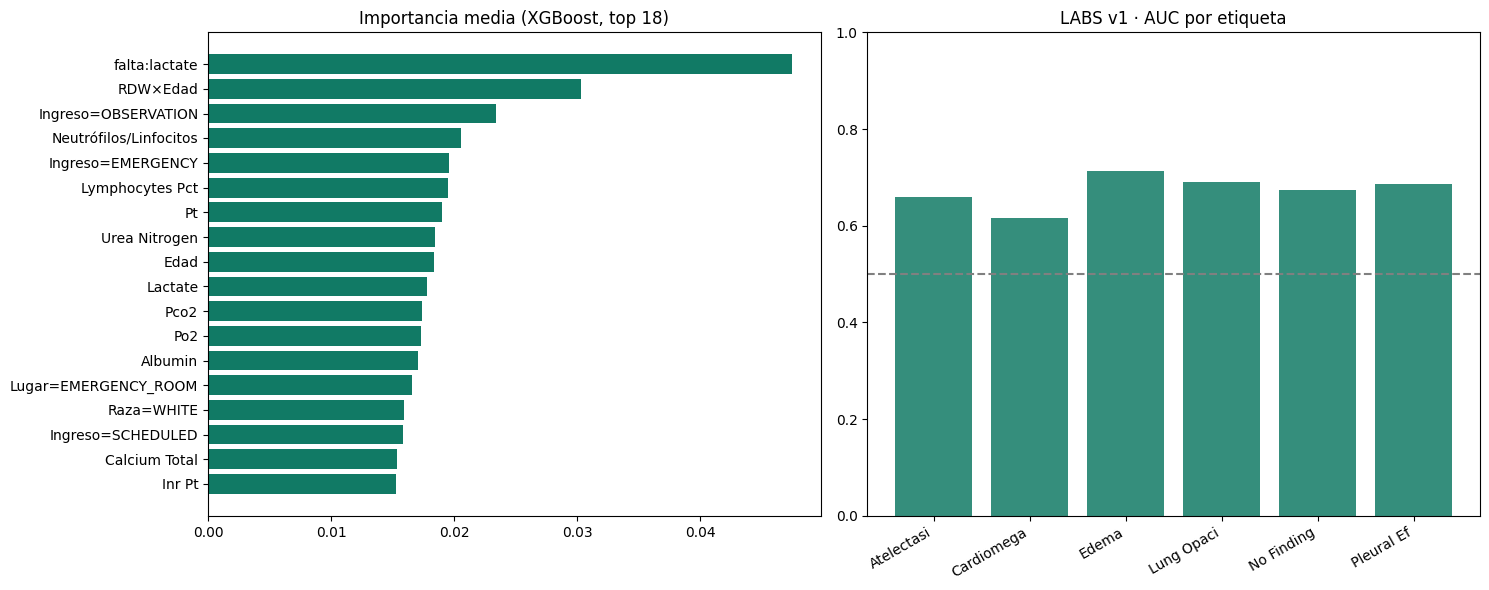

In [9]:
# CELDA 9 · IMPORTANCIA DE VARIABLES (nombres legibles) + AUC por etiqueta
imp=np.zeros(X_train.shape[1])
for j in range(N_LABELS):
    sel=m_train[:,j]==1; yj=y_train[sel,j]
    if len(np.unique(yj))<2: continue
    spw=(yj==0).sum()/max((yj==1).sum(),1); clf=make_xgb(spw); clf.fit(X_train[sel],yj)
    fi=clf.feature_importances_; imp+=fi/(fi.sum()+1e-9)
imp/=N_LABELS; order=np.argsort(imp)[::-1][:18]
fig,axes=plt.subplots(1,2,figsize=(15,6))
axes[0].barh([FEAT_NAMES[i] for i in order][::-1],[imp[i] for i in order][::-1],color="#117a65"); axes[0].set_title("Importancia media (XGBoost, top 18)")
aucs=[M[l]["AUC"] for l in LABELS]
axes[1].bar(range(N_LABELS),[0 if np.isnan(a) else a for a in aucs],color=["#c0392b" if (np.isnan(a) or a<0.6) else "#117a65" for a in aucs],alpha=0.85)
axes[1].axhline(0.5,color="gray",ls="--"); axes[1].set_xticks(range(N_LABELS)); axes[1].set_xticklabels([l[:10] for l in LABELS],rotation=30,ha="right")
axes[1].set_ylim(0,1); axes[1].set_title("LABS v1 · AUC por etiqueta")
plt.tight_layout(); plt.savefig(FIG/"importancia_auc_v1.png",dpi=150,bbox_inches="tight"); plt.show()

In [10]:
# CELDA 10 · EXPORTAR OOF/val/test PARA EL STACKING (hadm_id, labs_<label>, labs_<label>_cal)
def save_predictions(df, raw, cal, name):
    cols={"hadm_id":df["hadm_id"].to_numpy()}
    for j,l in enumerate(LABELS):
        key=l.replace(" ","_"); cols[f"labs_{key}"]=raw[:,j]; cols[f"labs_{key}_cal"]=cal[:,j]
    out=pd.DataFrame(cols); p=OUTPUT_DIR/f"labs_pred_{name}.csv"; out.to_csv(p,index=False); print("   guardado",p.name)
save_predictions(df_train, oof_train, oof_cal, "oof_train")
save_predictions(df_val, val_pred_raw, val_pred, "val")
save_predictions(df_test, test_pred_raw, test_pred, "test")
print("OOF/val/test del LABS v1 exportados.")

   guardado labs_pred_oof_train.csv
   guardado labs_pred_val.csv
   guardado labs_pred_test.csv
OOF/val/test del LABS v1 exportados.


---
## ✅ Resumen — LABS v1 (ligero)
**Un único XGBoost** one-vs-rest con NaN nativo, ratios clínicos (BUN/Creatinina, Neutrófilos/Linfocitos, RDW×Edad) y
flags de missingness. Mantiene masking, negativos derivados, balanceo, calibración y **OOF sin fuga**. Para más AUC, ver
**v2** (ensemble de 4 modelos) y **v3** (ensemble + TabPFN + stacking de 2º nivel).